In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df = pd.read_csv('/content/CarPrice_Assignment.csv')

In [3]:
df.shape

(205, 26)

In [4]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [5]:
num_col = df.select_dtypes(exclude = "object")
num_col.columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [6]:
colsDrp = ['symboling', 'carheight', 'stroke', "compressionratio", "peakrpm", "CarName"]
df.drop(columns = colsDrp, axis=1, inplace = True)

In [7]:
cat_col = df.select_dtypes(include = ["object"]).columns
df[cat_col].nunique()

,0
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
cylindernumber,7
fuelsystem,8


In [8]:
df = pd.get_dummies(columns=['fueltype', 'aspiration', 'doornumber', 'drivewheel', 'enginelocation'], data=df, drop_first= True )

In [9]:
df.head()

,car_ID,carbody,wheelbase,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,...,horsepower,citympg,highwaympg,price,fueltype_gas,aspiration_turbo,doornumber_two,drivewheel_fwd,drivewheel_rwd,enginelocation_rear
0,1,convertible,88.6,168.8,64.1,2548,dohc,four,130,mpfi,...,111,21,27,13495.0,True,False,True,False,True,False
1,2,convertible,88.6,168.8,64.1,2548,dohc,four,130,mpfi,...,111,21,27,16500.0,True,False,True,False,True,False
2,3,hatchback,94.5,171.2,65.5,2823,ohcv,six,152,mpfi,...,154,19,26,16500.0,True,False,True,False,True,False
3,4,sedan,99.8,176.6,66.2,2337,ohc,four,109,mpfi,...,102,24,30,13950.0,True,False,False,True,False,False
4,5,sedan,99.4,176.6,66.4,2824,ohc,five,136,mpfi,...,115,18,22,17450.0,True,False,False,False,False,False


In [10]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [11]:
encoder = OrdinalEncoder()
for i in df.select_dtypes(include='object').columns:
    df[i] = encoder.fit_transform(df[[i]])

In [12]:
X = df.drop('price', axis = 1)
y = df['price']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 20)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression, Ridge

**Model 1 : Multiple Linear Regression (All Features)**

In [17]:
rgsr = LinearRegression()

In [18]:
model = rgsr.fit(X_train_scaled, y_train)

In [19]:
y_pred = model.predict(X_test_scaled)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('--- MLR (All Features) ---')
print(f'Mean Absolute Error = {mae:.2f}')
print(f'Root Mean Squared Error = {rmse:.2f}')
print(f'R-Squared Score = {r2*100:.2f} %\n')

--- MLR (All Features) ---
Mean Absolute Error = 1970.16
Root Mean Squared Error = 2421.17
R-Squared Score = 83.18 %



**Visualization**

In [22]:
pip install yellowbrick

In [23]:
from yellowbrick.regressor import PredictionError

**Initialize the visualization model**

In [24]:
visualizer = PredictionError(rgsr)

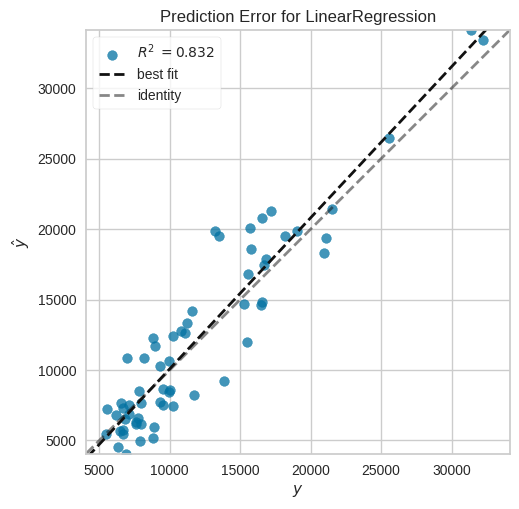

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [25]:
visualizer.fit(X_train_scaled, y_train)

visualizer.score(X_test_scaled, y_test)

visualizer.show()

In [26]:
#model 2-Feature selection (SFS)

In [27]:
rgsr=LinearRegression()

In [28]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs

In [29]:
selector=sfs(rgsr,n_features_to_select=5,direction='backward')
selector=selector.fit(X_train_scaled,y_train)

#get the names
selected_features=list(X.columns[selector.get_support()] )
print(selected_features)

#slice the orignal data frame
X_train_selected=X_train[selected_features]
X_test_selected=X_test[selected_features]

#Re scale
scaler_new=StandardScaler()
X_train_sel_scaled=scaler_new.fit_transform(X_train_selected)
X_test_sel_scaled=scaler_new.transform(X_test_selected)

#Fit the model
model=rgsr.fit(X_train_sel_scaled,y_train)

['car_ID', 'wheelbase', 'enginesize', 'horsepower', 'enginelocation_rear']


In [30]:
y_pred_sfs=model.predict(X_test_sel_scaled)

In [31]:
mae_sfs=mean_absolute_error(y_test,y_pred_sfs)
mse_sfs=mean_squared_error(y_test,y_pred_sfs)
rmse_sfs=np.sqrt(mse_sfs)
r2_sfs=r2_score(y_test,y_pred_sfs)
